### Neural Computing Individual Project: MLP Implementation

## 1. Setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix)
import torch
import torch.nn as nn
import time
import copy

## 2. Data Exploration

In [21]:
# Load dataset
data = load_breast_cancer()

# Extract features and labels
X = data.data
y = data.target

# Feature names
feature_names = data.feature_names

# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [22]:
# Dataset Summary
# Number of samples and features
n_samples, n_features = X.shape

# Class distribution
class_counts = np.bincount(y)

# Print summary
print("Dataset Summary")
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print("\nClass distribution:")
print(f"Malignant (0): {class_counts[0]}")
print(f"Benign (1): {class_counts[1]}")

Dataset Summary
Number of samples: 569
Number of features: 30

Class distribution:
Malignant (0): 212
Benign (1): 357


In [23]:
# Key Data 
print(data.DESCR) 

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

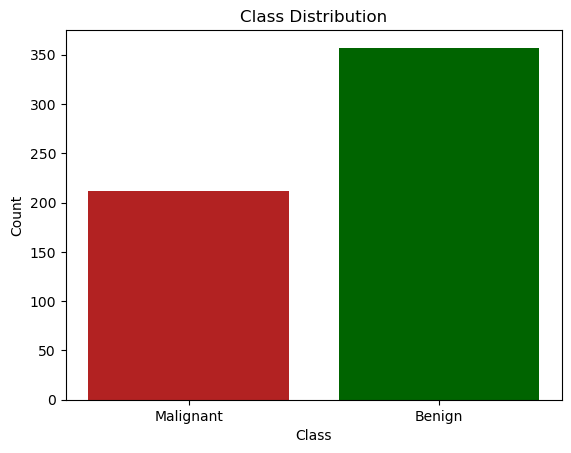

In [24]:
# Class Imbalance plot
plt.figure()
plt.bar(['Malignant', 'Benign'],
    class_counts,
    color=['firebrick', 'darkgreen'])

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Imbalance is not severe, but it is important to consider when evaluating model performance.  

In [25]:
# Summary statistics
summary_table = df.describe().T  # transpose for readability
summary_table

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


The summary statistics indicate substantial variation in feature scales across the dataset.
- For example, features such as *mean area* (mean ≈ 654, std ≈ 351) are on a much larger scale and show greater variability than features such as *mean smoothness* (mean ≈ 0.096, std ≈ 0.014) or *mean fractal dimension* (mean ≈ 0.063, std ≈ 0.007).
- This variation in both scale and spread indicates that the features are not standardised, meaning some variables could dominate the learning process. Therefore, feature standardisation is required prior to model training.

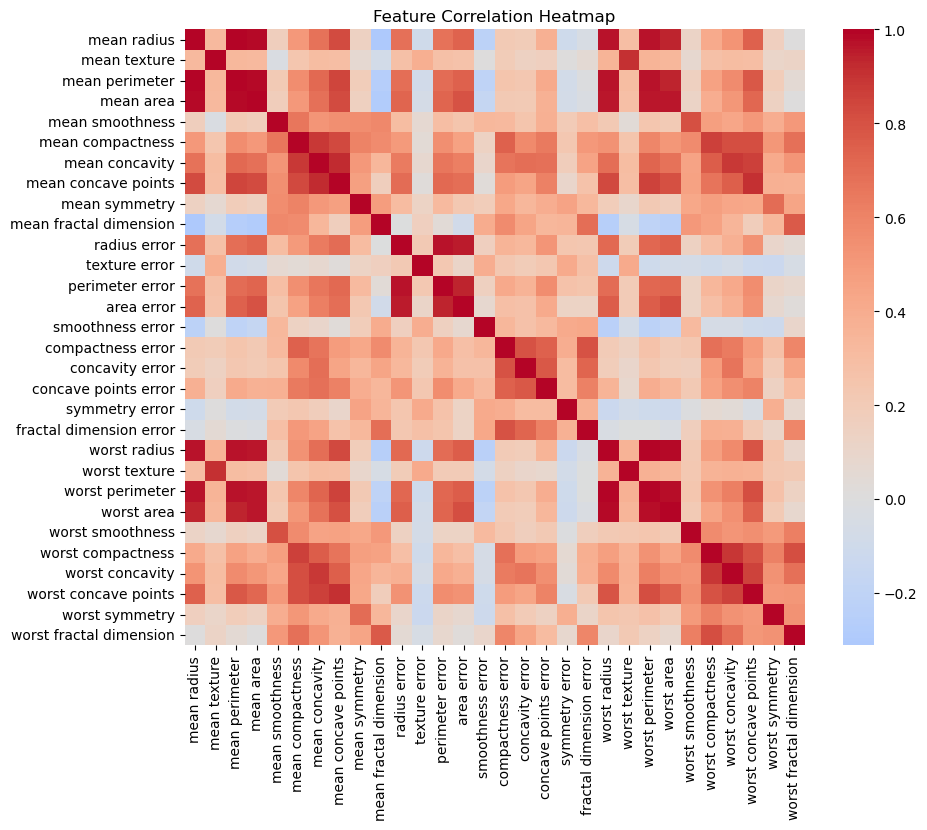

In [26]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.drop(columns='target').corr() # Dropping target variable
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

- The heatmap shows strong correlations between several features, particularly those derived from similar measurements (e.g. radius, perimeter, and area). This indicates that some features contain overlapping information, meaning that not all features contribute independently to the learning process. 
- For an MLP, this means the model may learn similar patterns repeatedly rather than learning new information, which can make training less efficient and increase the risk of overfitting.



## 3. Data Preprocessing

In [27]:
# Split the dataset into:
# 80% training data 
# 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=1,
    stratify=y) # ensures class balance is preserved)

# Print dataset sizes
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set: 455 samples (80.0%)
Test set:     114 samples (20.0%)


In [28]:
# Checking that stratification worked properly
# Expecting similar proportions of each class in train and test sets
print("\nTraining set class balance:")
unique, counts = np.unique(y_train, return_counts=True)

for val, count in zip(unique, counts):
    print(f"  Class {val}: {count} samples ({count/len(y_train)*100:.1f}%)")


print("\nTest set class balance:")
unique, counts = np.unique(y_test, return_counts=True)

for val, count in zip(unique, counts):
    print(f"  Class {val}: {count} samples ({count/len(y_test)*100:.1f}%)")


Training set class balance:
  Class 0: 170 samples (37.4%)
  Class 1: 285 samples (62.6%)

Test set class balance:
  Class 0: 42 samples (36.8%)
  Class 1: 72 samples (63.2%)


In [29]:
# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Apply same transformation seperately test data to avoid data leakage
X_test_scaled = scaler.transform(X_test)

## 4. Model Definition
The MLP has two hidden layers with ReLU activation and a Sigmoid output for binary classification.
Architecture: Input (30) → Hidden 1 (h1) → Hidden 2 (h2) → Output (1)

In [30]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super(MLP, self).__init__()
        # First layer: 30 input features > first hidden layer
        self.fc1 = nn.Linear(30, hidden_dim1)
        # Second layer: output of first hidden layer > second hidden layer
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        # Output layer: reduces to a single value for binary classification
        self.fc3 = nn.Linear(hidden_dim2, 1)

        # Defining the activation function
        # ReLU introduces non-linearity (allows learning complex patterns)
        self.relu = nn.ReLU()
        
        # Sigmoid squashes output to [0, 1] 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        
        # Pass through first hidden layer + activation
        x = self.fc1(x)
        x = self.relu(x)
        
        # Pass through second hidden layer + activation
        x = self.fc2(x)
        x = self.relu(x)
        
        # Final output layer > probability
        x = self.fc3(x)
        x = self.sigmoid(x)

        return x

## 5. Training Function
Trains with SGD + momentum (0.9) and L2 regularisation (weight decay). Early stopping monitors validation loss and restores the best weights when patience is exhausted.

In [31]:
# DEFINING THE TRAINING FUNCTION
def train_model(MLP_model, 
                X_train, y_train, 
                X_val, y_val, 
                learning_rate, 
                weight_decay, 
                num_epochs,
                patience=20,
                verbose=False):

    # Loss Function
    # Binary Cross-Entropy: for binary classification with a sigmoid output
    criterion = nn.BCELoss()
    
    # Optimiser
    # SGD with momentum 
    # weight_decay adds L2 regularisation: penalising large weights
    optimizer = torch.optim.SGD(
        MLP_model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=weight_decay)
    
    # Tracking
    # Store per-epoch losses so we can plot training curves afterwards.
    # Divergence between train_losses and val_losses is a sign of overfitting.
    train_losses = []
    val_losses = []
    
    # Early Stopping
    # best_val_loss: the lowest validation loss seen so far.
    # best_model_state: the weights at that best epoch.
    # epochs_no_improve: counter that increments each epoch without improvement
    # and resets to 0 whenever a new best is found.
    best_val_loss = float('inf') 
    best_model_state = copy.deepcopy(MLP_model.state_dict())
    epochs_no_improve = 0
    
    # Timing
    start_time = time.time()
    
    # Training Loop
    for epoch in range(num_epochs):
        
        MLP_model.train()
        
        # Reset gradients them each epoch
        optimizer.zero_grad()
        
        # Forward pass
        train_outputs = MLP_model(X_train)
        
        # Compute BCE loss
        train_loss = criterion(train_outputs, y_train)
        
        # Backward pass
        train_loss.backward()
        
        # Update weights in the direction that reduces training loss
        optimizer.step()
        
        # Validation
        MLP_model.eval()
        with torch.no_grad():
            val_outputs = MLP_model(X_val)
            val_loss = criterion(val_outputs, y_val)
        
        # Record both losses for this epoch
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        
        # Early Stopping Check
        # If validation loss improved: save these weights and reset the counter.
        # If not: increment the counter. 
        # Once it reaches `patience`, stop training
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(MLP_model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Print progress every 50 epochs to monitor training 
        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | "
                  f"Train Loss: {train_loss.item():.4f} | "
                  f"Val Loss: {val_loss.item():.4f}")
        
        # Stop training if patience is exhausted
        if epochs_no_improve >= patience:
           if verbose:
              print(f"\nEarly stopping at epoch {epoch+1} "
                  f"(no val loss improvement for {patience} consecutive epochs)")
           break
    
    # Restore the weights from the epoch with the lowest validation loss
    MLP_model.load_state_dict(best_model_state)
    
    training_time = time.time() - start_time
    
    return MLP_model, training_time, train_losses, val_losses

## 6. Hyperparameter Optimisation
5-fold stratified cross-validation across 27 configurations (3 hidden sizes × 3 learning rates × 3 weight decay values). Validation loss is averaged across folds to select the best configuration.

In [38]:
# HYPERPARAMETER OPTIMISATION
hidden_configs      = [(64, 32), (128, 64), (32, 16)]
learning_rates_list = [0.001, 0.01, 0.1]
weight_decays_list  = [0.0001, 0.001, 0.01]
num_epochs          = 200

total_experiments = len(hidden_configs) * len(learning_rates_list) * len(weight_decays_list)
print(f"Total experiments: {total_experiments} configurations × 5 folds = "
      f"{total_experiments * 5} training runs\n")

# 5-Fold Cross Validation
# StratifiedKFold preserves the class ratio (37/63) in each foldd
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_results = []
experiment_num = 0

for hidden_dim1, hidden_dim2 in hidden_configs:
    for learning_rate in learning_rates_list:
        for weight_decay in weight_decays_list:
            
            experiment_num += 1
            fold_val_losses = []
            fold_times = []
            
            for fold, (train_idx, val_idx) in enumerate(
                    kfold.split(X_train, y_train), 1):
                
                # Fold data preparation 
                X_train_fold = X_train[train_idx]
                X_val_fold   = X_train[val_idx]
                y_train_fold = y_train[train_idx]
                y_val_fold   = y_train[val_idx]
                
                # Scale inside the fold
                scaler = StandardScaler()
                X_train_fold = scaler.fit_transform(X_train_fold)
                X_val_fold   = scaler.transform(X_val_fold)
                
                # Convert to tensors
                X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
                X_val_fold   = torch.tensor(X_val_fold,   dtype=torch.float32)
                y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
                y_val_fold   = torch.tensor(y_val_fold,   dtype=torch.float32).view(-1, 1)
                
                # Fresh model for each fold 
                MLP_model_val = MLP(input_dim=X_train.shape[1],
                                    hidden_dim1=hidden_dim1,
                                    hidden_dim2=hidden_dim2)
                
                trained_model, fold_time, train_losses, val_losses = train_model(
                    MLP_model_val,
                    X_train_fold, y_train_fold,
                    X_val_fold, y_val_fold,
                    learning_rate=learning_rate,
                    weight_decay=weight_decay,
                    num_epochs=num_epochs,
                    patience=20)
                
                fold_val_losses.append(min(val_losses))
                fold_times.append(fold_time)
            
            mean_val_loss = np.mean(fold_val_losses)
            mean_time     = np.mean(fold_times)
            
            # One summary line per experiment
            print(f"[{experiment_num:02d}/{total_experiments}] "
                  f"hidden=({hidden_dim1},{hidden_dim2}) | "
                  f"lr={learning_rate} | wd={weight_decay} | "
                  f"mean_val_loss={mean_val_loss:.4f} | "
                  f"time={mean_time:.3f}s")
            
            cv_results.append({
                'hidden_dim1':    hidden_dim1,
                'hidden_dim2':    hidden_dim2,
                'learning_rate':  learning_rate,
                'weight_decay':   weight_decay,
                'mean_val_loss':  mean_val_loss,
                'fold_val_losses': fold_val_losses,
                'mean_time':      mean_time
            })

Total experiments: 27 configurations × 5 folds = 135 training runs

[01/27] hidden=(64,32) | lr=0.001 | wd=0.0001 | mean_val_loss=0.4728 | time=0.114s
[02/27] hidden=(64,32) | lr=0.001 | wd=0.001 | mean_val_loss=0.4430 | time=0.112s
[03/27] hidden=(64,32) | lr=0.001 | wd=0.01 | mean_val_loss=0.4856 | time=0.109s
[04/27] hidden=(64,32) | lr=0.01 | wd=0.0001 | mean_val_loss=0.0791 | time=0.107s
[05/27] hidden=(64,32) | lr=0.01 | wd=0.001 | mean_val_loss=0.0778 | time=0.105s
[06/27] hidden=(64,32) | lr=0.01 | wd=0.01 | mean_val_loss=0.0761 | time=0.111s
[07/27] hidden=(64,32) | lr=0.1 | wd=0.0001 | mean_val_loss=0.0753 | time=0.026s
[08/27] hidden=(64,32) | lr=0.1 | wd=0.001 | mean_val_loss=0.0701 | time=0.026s
[09/27] hidden=(64,32) | lr=0.1 | wd=0.01 | mean_val_loss=0.0668 | time=0.034s
[10/27] hidden=(128,64) | lr=0.001 | wd=0.0001 | mean_val_loss=0.3576 | time=6.395s
[11/27] hidden=(128,64) | lr=0.001 | wd=0.001 | mean_val_loss=0.3803 | time=6.291s
[12/27] hidden=(128,64) | lr=0.001 |

In [41]:
# RESULTS SUMMARY
# Convert results to a DataFrame for easy sorting and plotting
results_df = pd.DataFrame(cv_results)

# Best configuration
best = results_df.loc[results_df['mean_val_loss'].idxmin()]
print("Best configuration found:")
print(f"  Hidden layers : ({int(best.hidden_dim1)}, {int(best.hidden_dim2)})")
print(f"  Learning rate : {best.learning_rate}")
print(f"  Weight decay  : {best.weight_decay}")
print(f"  Mean val loss : {best.mean_val_loss:.4f}")

Best configuration found:
  Hidden layers : (32, 16)
  Learning rate : 0.1
  Weight decay  : 0.001
  Mean val loss : 0.0652


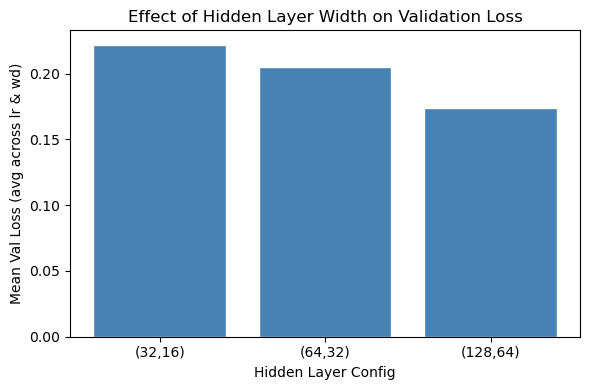

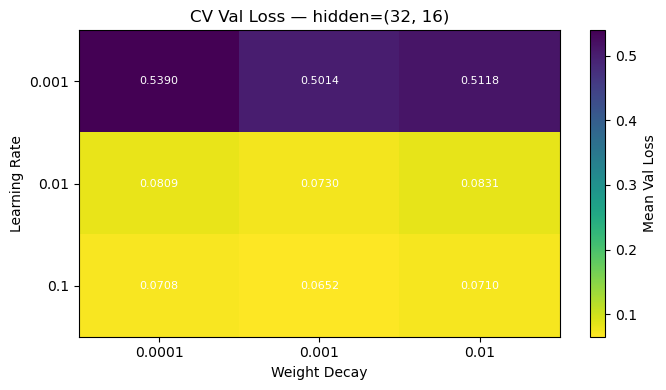

In [42]:
# RESULTS SUMMARY VISUALISATION
# Bar chart: mean val loss per hidden config
config_means = results_df.groupby(
    ['hidden_dim1', 'hidden_dim2'])['mean_val_loss'].mean()

plt.figure(figsize=(6, 4))
labels = [f"({int(h1)},{int(h2)})" for h1, h2 in config_means.index]
plt.bar(labels, config_means.values, color='steelblue', edgecolor='white')
plt.ylabel('Mean Val Loss (avg across lr & wd)')
plt.xlabel('Hidden Layer Config')
plt.title('Effect of Hidden Layer Width on Validation Loss')
plt.tight_layout()
plt.show()


# Heatmap: learning rate vs weight decay (for best hidden config)
best_hidden = (int(best.hidden_dim1), int(best.hidden_dim2))
subset = results_df[
    (results_df.hidden_dim1 == best_hidden[0]) &
    (results_df.hidden_dim2 == best_hidden[1])
].pivot(index='learning_rate', columns='weight_decay', values='mean_val_loss')

plt.figure(figsize=(7, 4))
plt.imshow(subset.values, cmap='viridis_r', aspect='auto')
plt.colorbar(label='Mean Val Loss')
plt.xticks(range(len(subset.columns)), subset.columns)
plt.yticks(range(len(subset.index)), subset.index)
plt.xlabel('Weight Decay')
plt.ylabel('Learning Rate')
plt.title(f'CV Val Loss — hidden={best_hidden}')
for i in range(len(subset.index)):
    for j in range(len(subset.columns)):
        plt.text(j, i, f"{subset.values[i,j]:.4f}",
                 ha='center', va='center', color='white', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Final Model Training
Retraining a single model with the best hyperparameters on the full training set (80% of data). A small 10% holdout is used solely for early stopping.

In [61]:
# RETRAINING THE BEST MODEL 
# Retrieve best hyperparameters from cross-validation results
best_hidden_dim1 = int(best.hidden_dim1)
best_hidden_dim2 = int(best.hidden_dim2)
best_lr          = best.learning_rate
best_wd          = best.weight_decay

print("Retraining with best configuration:")
print(f"  Hidden layers  : ({best_hidden_dim1}, {best_hidden_dim2})")
print(f"  Learning rate  : {best_lr}")
print(f"  Weight decay   : {best_wd}")
print(f"  Best CV val loss (reference) : {results_df['mean_val_loss'].min():.4f}")

# Small internal holdout for early stopping only
# Stratified to preserve the class ratio in both splits
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train_scaled, y_train,
    test_size=0.1,
    random_state=1,
    stratify=y_train)

# Convert to tensors
X_tr_final_t  = torch.tensor(X_tr_final,  dtype=torch.float32)
y_tr_final_t  = torch.tensor(y_tr_final,  dtype=torch.float32).view(-1, 1)
X_val_final_t = torch.tensor(X_val_final, dtype=torch.float32)
y_val_final_t = torch.tensor(y_val_final, dtype=torch.float32).view(-1, 1)

# Fresh model with best hyperparameters
best_model = MLP(input_dim=30,
                 hidden_dim1=best_hidden_dim1,
                 hidden_dim2=best_hidden_dim2)

# Train with verbose=True so we can monitor convergence
best_model, training_time, train_losses, val_losses = train_model(
    best_model,
    X_tr_final_t, y_tr_final_t,
    X_val_final_t, y_val_final_t,
    learning_rate=best_lr,
    weight_decay=best_wd,
    num_epochs=200,
    patience=20,
    verbose=True)

print(f"\nTotal training time: {training_time:.2f}s") 

Retraining with best configuration:
  Hidden layers  : (32, 16)
  Learning rate  : 0.1
  Weight decay   : 0.001
  Best CV val loss (reference) : 0.0652

Early stopping at epoch 46 (no val loss improvement for 20 consecutive epochs)

Total training time: 0.04s


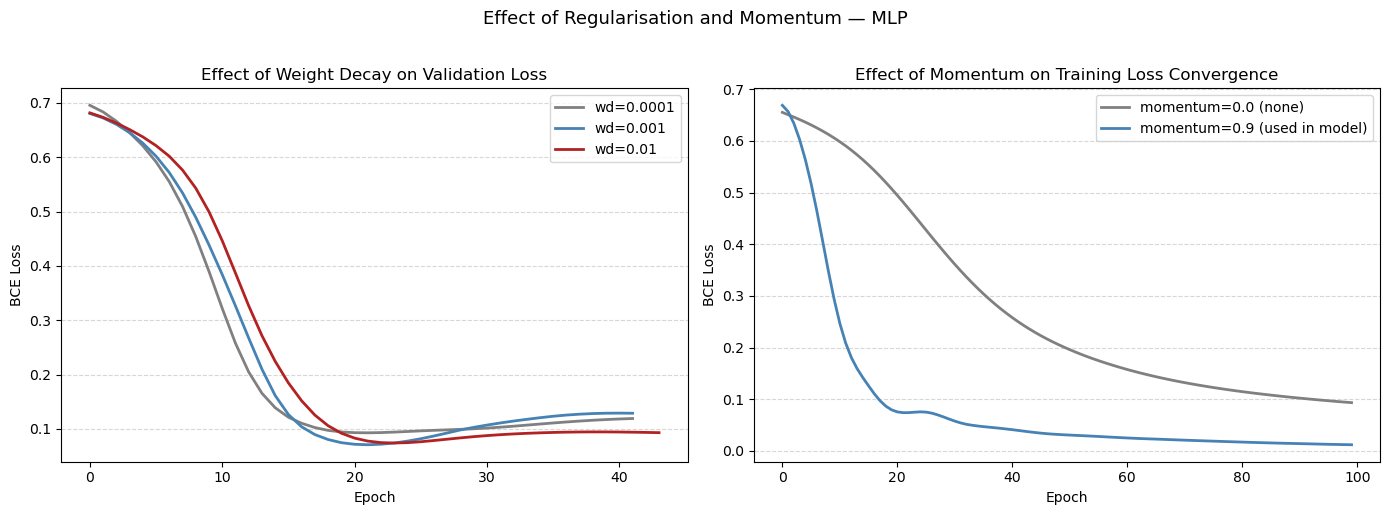

In [62]:
# LOSS CURVES 1 - EFFECT OF WEIGHT DECAY AND MOMENTUM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of weight decay 
# Values match those searched during hyperparameter optimisation
wd_values = [0.0001, 0.001, 0.01]
wd_colors = ['grey', 'steelblue', 'firebrick']

for wd, col in zip(wd_values, wd_colors):
    model_temp = MLP(input_dim=30, hidden_dim1=best_hidden_dim1,
                     hidden_dim2=best_hidden_dim2)
    _, _, _, val_losses_temp = train_model(
        model_temp,
        X_tr_final_t, y_tr_final_t,
        X_val_final_t, y_val_final_t,
        learning_rate=best_lr,
        weight_decay=wd,
        num_epochs=200,
        patience=20)
    axes[0].plot(val_losses_temp, label=f'wd={wd}', color=col, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Effect of Weight Decay on Validation Loss')
axes[0].legend()
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)

# Plot 2: Effect of momentum 
# Comparing no momentum (0.0) vs the value used in the final model (0.9)
momentum_values = [0.0, 0.9]
mom_colors      = ['grey', 'steelblue']
mom_labels      = ['momentum=0.0 (none)', 'momentum=0.9 (used in model)']

for mom, col, lbl in zip(momentum_values, mom_colors, mom_labels):
    model_temp = MLP(input_dim=30, hidden_dim1=best_hidden_dim1,
                     hidden_dim2=best_hidden_dim2)

    # Momentum is not a parameter of train_model so we run a short manual loop here
    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(model_temp.parameters(),
                                lr=best_lr,
                                momentum=mom,
                                weight_decay=best_wd)
    train_losses_temp = []
    for epoch in range(100):
        model_temp.train()
        optimizer.zero_grad()
        out  = model_temp(X_tr_final_t)
        loss = criterion(out, y_tr_final_t)
        loss.backward()
        optimizer.step()
        train_losses_temp.append(loss.item())

    axes[1].plot(train_losses_temp, label=lbl, color=col, linewidth=2)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Effect of Momentum on Training Loss Convergence')
axes[1].legend()
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)

plt.suptitle('Effect of Regularisation and Momentum — MLP',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

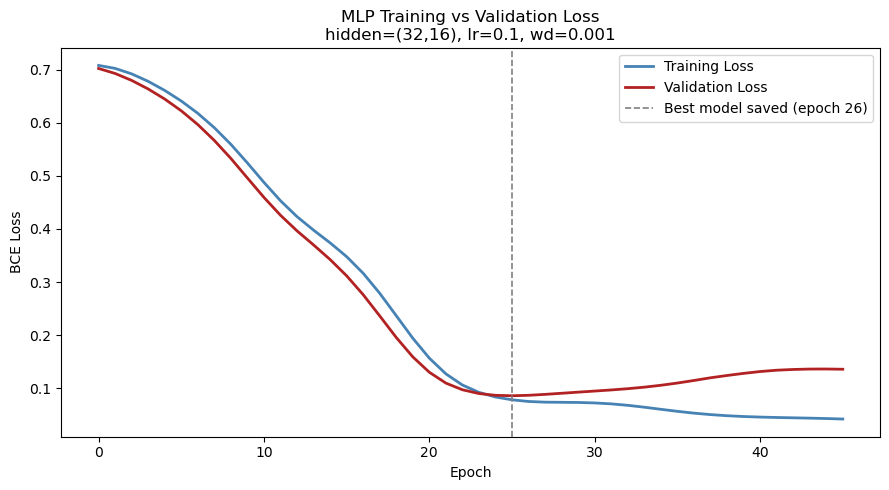

Lowest validation loss : 0.0856 at epoch 26
Final training loss    : 0.0417


In [63]:
# LOSS CURVES 2 - FINAL MODEL TRAINING AND VALIDATION LOSS
best_epoch = int(np.argmin(val_losses))

plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Validation Loss', color='firebrick', linewidth=2)

# Mark where early stopping restored the best weights from
plt.axvline(x=best_epoch,
            color='grey', linestyle='--', linewidth=1.2,
            label=f'Best model saved (epoch {best_epoch + 1})')

plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title(f'MLP Training vs Validation Loss\n'
          f'hidden=({best_hidden_dim1},{best_hidden_dim2}), '
          f'lr={best_lr}, wd={best_wd}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest validation loss : {min(val_losses):.4f} at epoch {best_epoch + 1}")
print(f"Final training loss    : {train_losses[-1]:.4f}")

Training converged quickly with early stopping triggered at epoch 46, and the best weights saved at epoch 25. The gap between training loss and validation loss at the stopping point indicates mild overfitting. 

## 8. Evaluation

In [ ]:
# VALIDATION PERFORMANCE 
best_model.eval()
with torch.no_grad():
    val_probs = best_model(X_val_final_t)

    # Convert probabilities to binary class predictions
    # Threshold of 0.5: >= 0.5 → Benign (1), < 0.5 → Malignant (0)
    val_preds = (val_probs >= 0.5).float().numpy().flatten()

val_accuracy  = accuracy_score(y_val_final, val_preds)
val_precision = precision_score(y_val_final, val_preds)
val_recall    = recall_score(y_val_final, val_preds)
val_f1        = f1_score(y_val_final, val_preds)

print("Validation Set Performance")
print(f"  Accuracy  : {val_accuracy:.4f}")
print(f"  Precision : {val_precision:.4f}")
print(f"  Recall    : {val_recall:.4f}")
print(f"  F1 Score  : {val_f1:.4f}")

Validation accuracy of 97.8% with perfect recall (1.0) on the malignant class, no malignant cases were missed. Precision of 0.967 indicates one false positive. Given the clinical context, high recall on the malignant class is the priority, so this is a strong result.

In [64]:
# TEST SET EVALUATION 
# X_test_scaled was scaled previously
# The test set has not been used at any point before this cell
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

best_model.eval()
with torch.no_grad():
    test_probs = best_model(X_test_t)
    test_preds = (test_probs >= 0.5).float().numpy().flatten()

test_accuracy  = accuracy_score(y_test,  test_preds)
test_precision = precision_score(y_test, test_preds)
test_recall    = recall_score(y_test,    test_preds)
test_f1        = f1_score(y_test,        test_preds)

print("Test Set Performance")
print(f"  Accuracy       : {test_accuracy:.4f}")
print(f"  Precision      : {test_precision:.4f}")
print(f"  Recall         : {test_recall:.4f}")
print(f"  F1 Score       : {test_f1:.4f}")

Test Set Performance
  Accuracy       : 0.9737
  Precision      : 0.9859
  Recall         : 0.9722
  F1 Score       : 0.9790


## 9. Results Summary

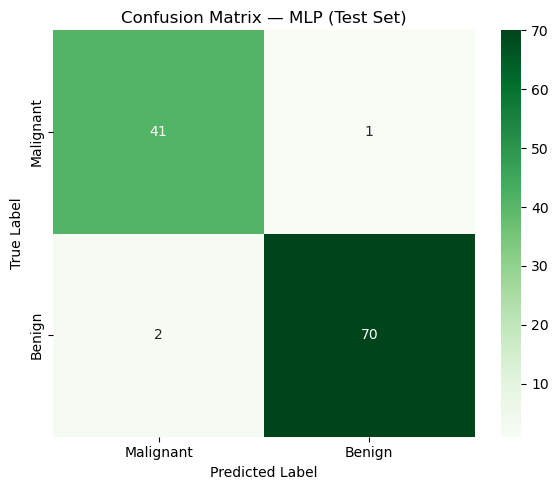

True Negatives  (Malignant correctly identified) : 41
False Positives (Malignant predicted as Benign)  : 1  ← missed malignant
False Negatives (Benign predicted as Malignant)  : 2
True Positives  (Benign correctly identified)    : 70
  Malignant Recall : 0.9762  ← % of malignant cases correctly identified


In [65]:
# CONFUSION MATRIX 
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — MLP (Test Set)')
plt.tight_layout()
plt.show()

# Explicit breakdown so errors are easy to reference in the paper
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Malignant correctly identified) : {tn}")
print(f"False Positives (Malignant predicted as Benign)  : {fp}  ← missed malignant")
print(f"False Negatives (Benign predicted as Malignant)  : {fn}")
print(f"True Positives  (Benign correctly identified)    : {tp}")

# Recall on malignant class (class 0) clinically the most important metric
malignant_recall = recall_score(y_test, test_preds, pos_label=0)
print(f"  Malignant Recall : {malignant_recall:.4f}  ← % of malignant cases correctly identified")

In [53]:
# Save MLP test predictions for cross-model comparison
np.save('mlp_test_preds.npy', test_preds)
print("MLP predictions saved")

MLP predictions saved


In [ ]:
# SAVE BEST MODEL WEIGHTS AND SCALER FOR SUBMISSION
# Allows the best model to be loaded and evaluated without retraining
import joblib
import os

os.makedirs('Submission_Files', exist_ok=True)

# Save trained model weights
torch.save(best_model.state_dict(), 'Submission_Files/mlp_best_weights.pt')

# Save the scaler fitted on training data
# Must be applied to any new test data before passing to the model
joblib.dump(scaler, 'Submission_Files/mlp_scaler.pkl')

# Save the test set so the marker can reproduce the exact evaluation
np.save('Submission_Files/X_test.npy', X_test)
np.save('Submission_Files/y_test.npy', y_test)

# Saving loss history for graphs later
np.save('submission_files/mlp_train_losses.npy', np.array(train_losses))
np.save('submission_files/mlp_val_losses.npy',   np.array(val_losses))
np.save('submission_files/mlp_best_epoch.npy',   np.array(best_epoch))